# Eksplorasi Analisis & Prediksi Harga Pangan Tingkat Subkategori Menggunakan Prophet
Notebook ini berisi alur lengkap proses analisis deret waktu (*time series*) dan pembuatan model prediksi menggunakan Facebook Prophet untuk seluruh subkategori komoditas pangan nasional berdasarkan data dari Bank Indonesia.

### Alur Pengerjaan:
1. **Data Collecting**: Mengambil data harga dari local dataset `dataset/commodity_history.json` untuk 21 subkategori komoditas pangan (Subkategori Level 2).
2. **Exploratory Data Analysis (EDA)**: Menganalisis karakteristik data secara visual dan stasioneritas (ADF Test) untuk seluruh subkategori.
3. **Data Preprocessing**: Format ulang data menjadi kolom `ds` (untuk tanggal) dan `y` (untuk nilai harga) sesuai spesifikasi Prophet.
4. **Model Training & Seasonality Customization**: Menyesuaikan parameter sensitivitas tren (`changepoint_prior_scale`) dan tipe musiman (additive vs multiplicative), serta menambahkan musiman mingguan dan tahunan secara eksplisit.
5. **Model Evaluation & Diagnostics**: Evaluasi dengan pembagian data latih/uji (train/test split) temporal secara kronologis (80% train, 20% test). Prophet dievaluasi menggunakan metrik statistik (MAE, RMSE, MAPE, R2) dan visualisasi terpisah untuk 4 subkategori kunci.


In [1]:
import warnings
import logging
# Suppress warnings and logger logs globally before importing packages
warnings.filterwarnings('ignore')
logging.disable(logging.CRITICAL)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from datetime import datetime, timedelta
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Re-enable logging after imports
logging.disable(logging.NOTSET)
# Disable info/warning logs for prophet & cmdstanpy specifically
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

# Pengaturan visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

## 1. Data Collecting
Kami menggunakan data harian dari local dataset `dataset/commodity_history.json` untuk 10 kategori bahan pokok (di tingkat subkategori level 2) berikut:
- `cat_1` (Beras)
- `cat_2` (Daging Ayam)
- `cat_3` (Daging Sapi)
- `cat_4` (Telur Ayam)
- `cat_5` (Bawang Merah)
- `cat_6` (Bawang Putih)
- `cat_7` (Cabai Merah)
- `cat_8` (Cabai Rawit)
- `cat_9` (Minyak Goreng)
- `cat_10` (Gula Pasir)

Rentang waktu yang digunakan adalah dari 01 Januari 2024 hingga 24 Mei 2026. Untuk efisiensi, data disimpan ke cache file `raw_market_prices_subcategory_cache.csv`.


In [2]:
# List kategori komoditas berdasarkan request
categories = {
    "cat_1": "Beras",
    "cat_2": "Daging Ayam",
    "cat_3": "Daging Sapi",
    "cat_4": "Telur Ayam",
    "cat_5": "Bawang Merah",
    "cat_6": "Bawang Putih",
    "cat_7": "Cabai Merah",
    "cat_8": "Cabai Rawit",
    "cat_9": "Minyak Goreng",
    "cat_10": "Gula Pasir"
}

json_path = "dataset/commodity_history.json"
cache_file = "raw_market_prices_subcategory_cache.csv"

if os.path.exists(cache_file):
    print(f"Menemukan file cache lokal '{cache_file}'. Membaca data cache...")
    df_raw = pd.read_csv(cache_file)
else:
    import json
    print(f"Membaca data dari local dataset '{json_path}'...")
    if not os.path.exists(json_path):
        raise FileNotFoundError(f"File dataset tidak ditemukan di: {json_path}")
        
    with open(json_path, "r", encoding="utf-8") as f:
        json_data = json.load(f)
        
    raw_data_list = []
    
    current_category = None
    # Filter dan strukturkan data agar sesuai format wide dataframe sebelumnya
    for item in json_data["data"]:
        level = item.get("level")
        name = item.get("name")
        if level == 1:
            current_category = name
        elif level == 2:
            if current_category in categories.values():
                row_dict = {"Category": current_category, "Subcategory": name}
                
                # Ambil semua data tanggal (key format DD/MM/YYYY)
                for key, value in item.items():
                    if "/" in key and len(key.split("/")) == 3:
                        row_dict[key] = value
                        
                raw_data_list.append(row_dict)
                print(f"Berhasil memuat data untuk subkategori: {name} (Kategori: {current_category})")
            
    df_raw = pd.DataFrame(raw_data_list)
    
    if not df_raw.empty:
        df_raw.to_csv(cache_file, index=False)
        print(f"Sukses menyimpan data ke cache file '{cache_file}'.")
    else:
        raise ValueError("Gagal memperoleh data dari dataset JSON. Periksa format data.")

print("\nDimensi data mentah:", df_raw.shape)
df_raw.head()


Menemukan file cache lokal 'raw_market_prices_subcategory_cache.csv'. Membaca data cache...

Dimensi data mentah: (21, 877)


,Category,Subcategory,01/01/2024,02/01/2024,03/01/2024,04/01/2024,05/01/2024,06/01/2024,07/01/2024,08/01/2024,...,15/05/2026,16/05/2026,17/05/2026,18/05/2026,19/05/2026,20/05/2026,21/05/2026,22/05/2026,23/05/2026,24/05/2026
0,Beras,Beras Kualitas Bawah I,"13,550","13,650","13,650","13,650","13,650","13,650","13,650","13,650",...,"14,550","14,100","14,100","14,550","14,550","14,550","14,600","14,600","14,100","14,100"
1,Beras,Beras Kualitas Bawah II,"13,200","13,400","13,400","13,400","13,400","13,400","13,400","13,400",...,"14,550","14,600","14,600","14,550","14,550","14,450","14,450","14,450","14,600","14,600"
2,Beras,Beras Kualitas Medium I,"14,650","14,750","14,750","14,750","14,750","14,750","14,750","14,750",...,"16,150","15,750","15,750","16,150","16,150","16,150","16,150","16,150","15,750","15,750"
3,Beras,Beras Kualitas Medium II,"14,400","14,550","14,600","14,600","14,550","14,550","14,550","14,600",...,"16,000","15,450","15,450","16,000","16,000","16,000","16,000","16,000","15,450","15,450"
4,Beras,Beras Kualitas Super I,"15,850","16,050","16,050","16,050","16,050","16,050","16,050","16,050",...,"17,400","16,850","16,850","17,400","17,400","17,400","17,450","17,450","16,850","16,850"


## 2. Exploratory Data Analysis (EDA)
Pada bagian ini, kita akan:
1. Mengubah bentuk data mentah (wide format) menjadi format panjang (long format/tidy data) agar mudah dianalisis dan dimodelkan.
2. Membersihkan nilai harga pangan (menghilangkan tanda koma pemisah ribuan dan mengonversi ke tipe data numerik).
3. Memvisualisasikan tren harga dari seluruh subkategori komoditas pangan secara terpisah (satu per satu).
4. Melakukan uji stasioneritas menggunakan **Augmented Dickey-Fuller (ADF) Test** untuk seluruh subkategori guna mengetahui karakteristik tren.


In [3]:
# Transformasi dari Wide ke Long format
long_data = []

for idx, row in df_raw.iterrows():
    category = row["Category"]
    subcategory = row["Subcategory"]

    for col in df_raw.columns:
        if "/" in col:
            val_str = str(row[col]).strip()
            if val_str and val_str not in ["-", "null", "None", "nan"]:
                try:
                    price = float(val_str.replace(",", ""))
                    date_val = datetime.strptime(col, "%d/%m/%Y").date()
                    long_data.append({
                        "Date": date_val,
                        "Category": category,
                        "Subcategory": subcategory,
                        "Price": price
                    })
                except ValueError:
                    pass

df_tidy = pd.DataFrame(long_data)
df_tidy["Date"] = pd.to_datetime(df_tidy["Date"])
df_tidy = df_tidy.sort_values(by=["Category", "Subcategory", "Date"]).reset_index(drop=True)

print("Dimensi data bersih:", df_tidy.shape)
print("\nStatistik Deskriptif Subkategori:")
print(df_tidy.groupby(["Category", "Subcategory"])["Price"].describe())


Dimensi data bersih: (18375, 4)

Statistik Deskriptif Subkategori:
                                               count           mean  \
Category      Subcategory                                             
Bawang Merah  Bawang Merah Ukuran Sedang       875.0   42839.828571   
Bawang Putih  Bawang Putih Ukuran Sedang       875.0   42381.942857   
Beras         Beras Kualitas Bawah I           875.0   14263.028571   
              Beras Kualitas Bawah II          875.0   14096.685714   
              Beras Kualitas Medium I          875.0   15621.485714   
              Beras Kualitas Medium II         875.0   15480.000000   
              Beras Kualitas Super I           875.0   16918.228571   
              Beras Kualitas Super II          875.0   16437.828571   
Cabai Merah   Cabai Merah Besar                875.0   51157.542857   
              Cabai Merah Keriting             875.0   51412.171429   
Cabai Rawit   Cabai Rawit Hijau                875.0   49954.857143   
          

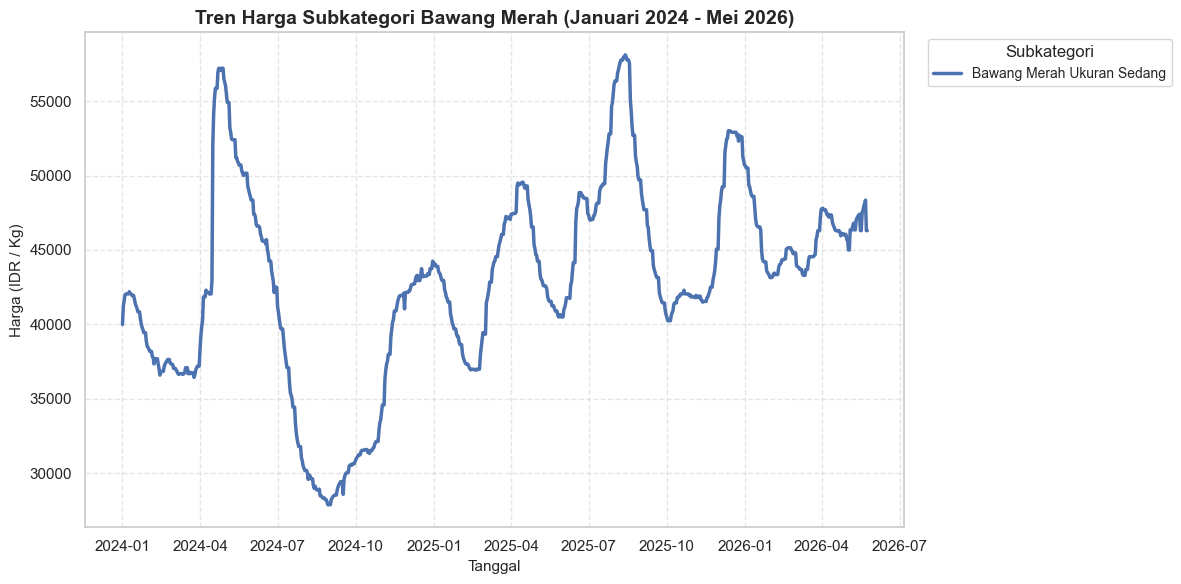

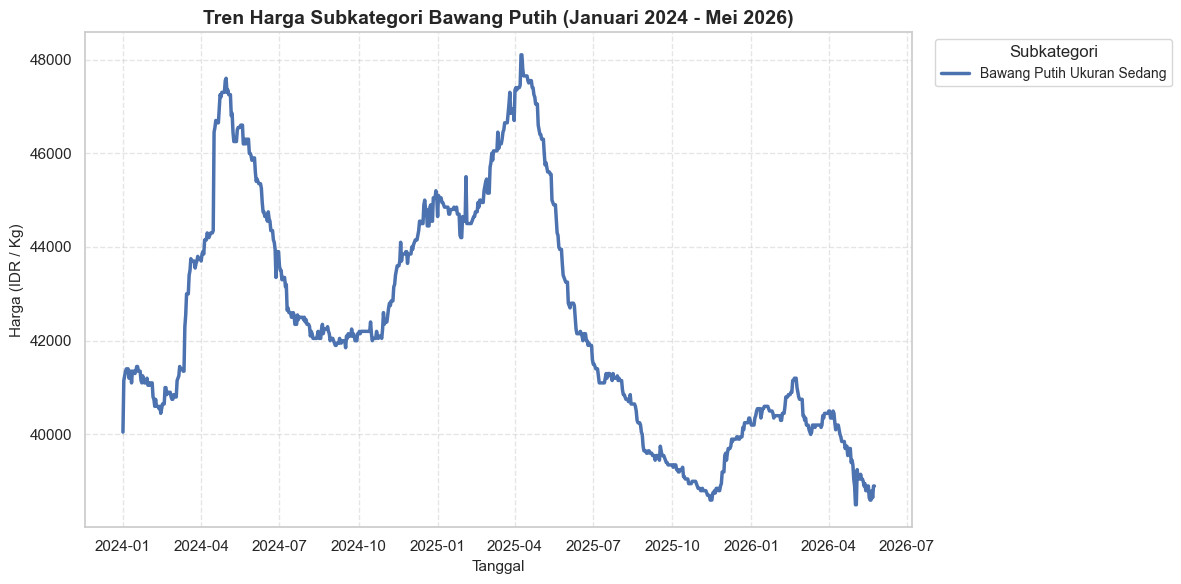

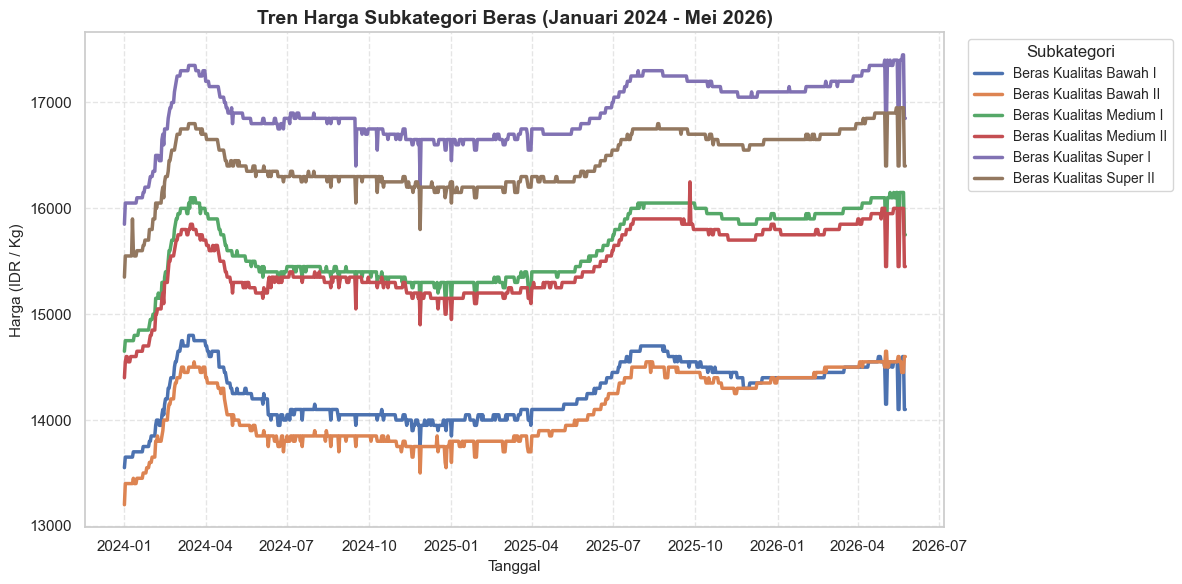

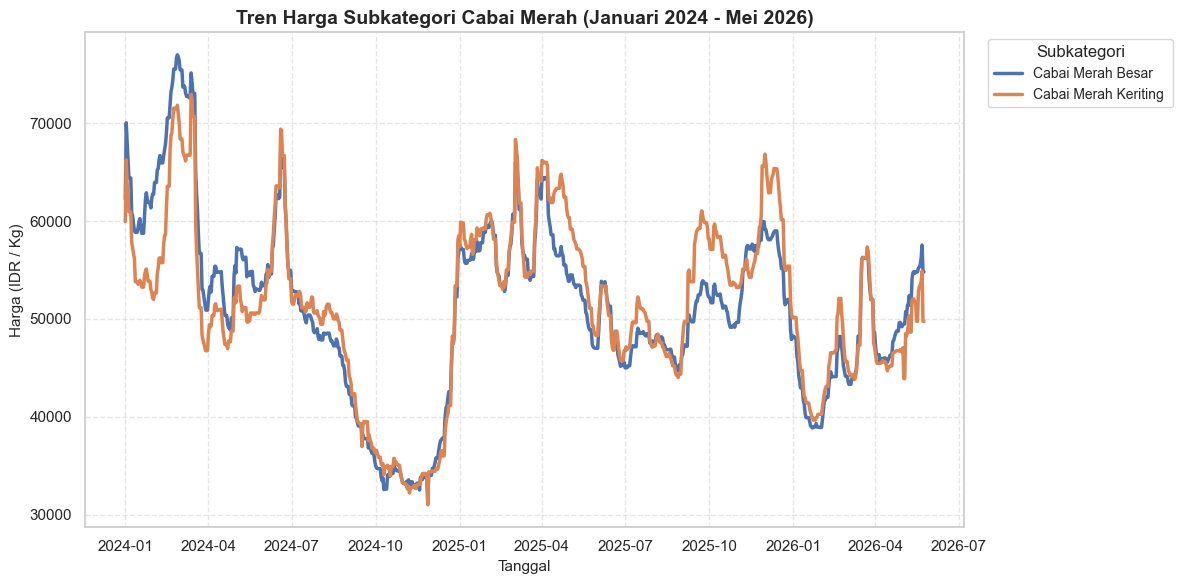

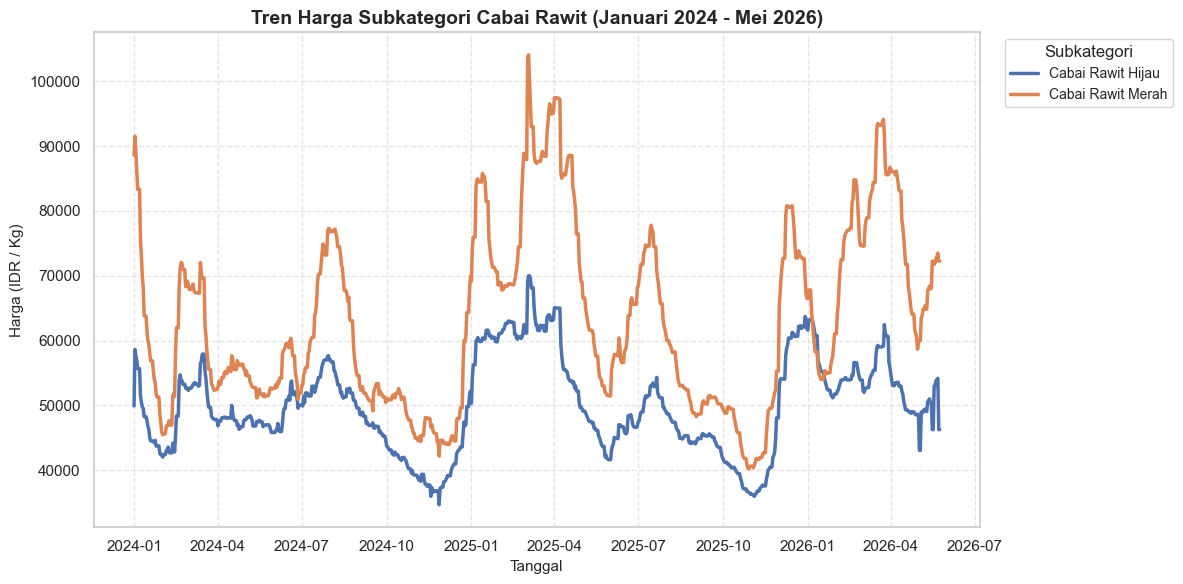

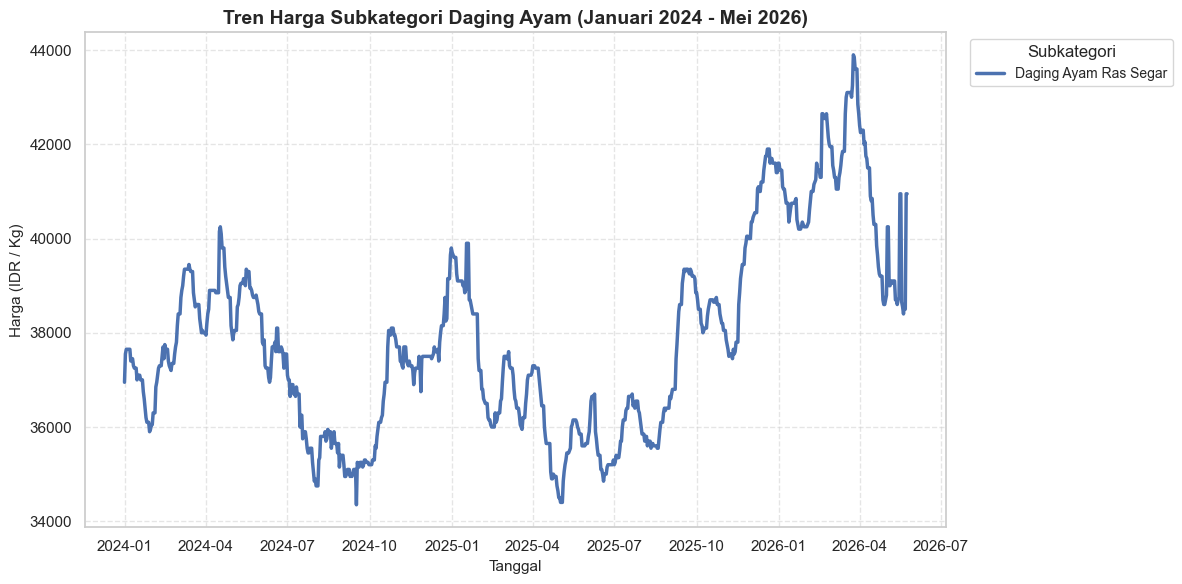

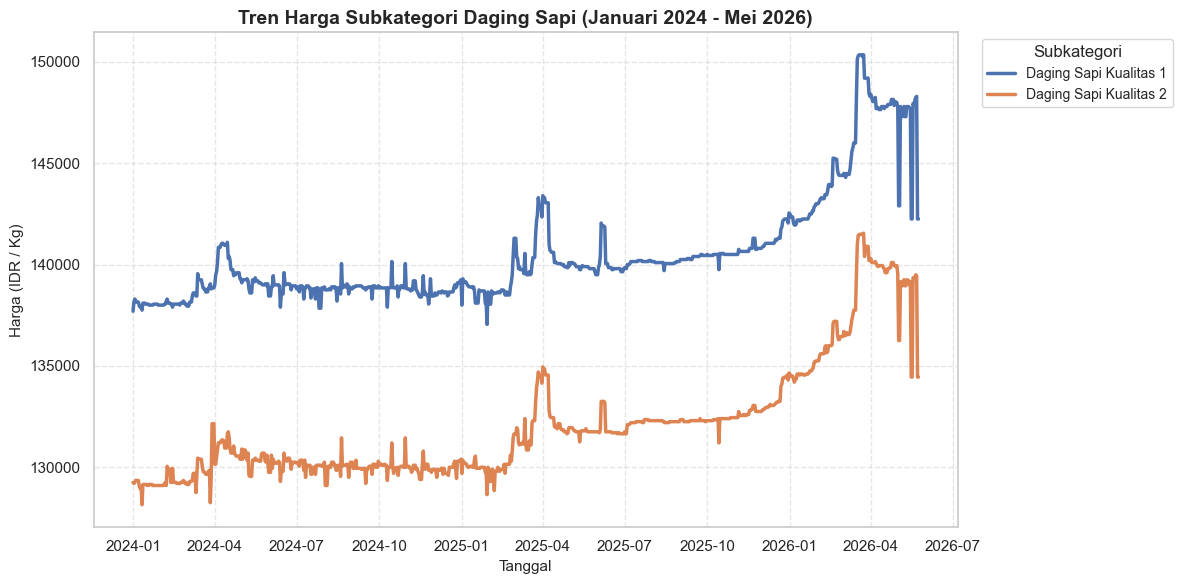

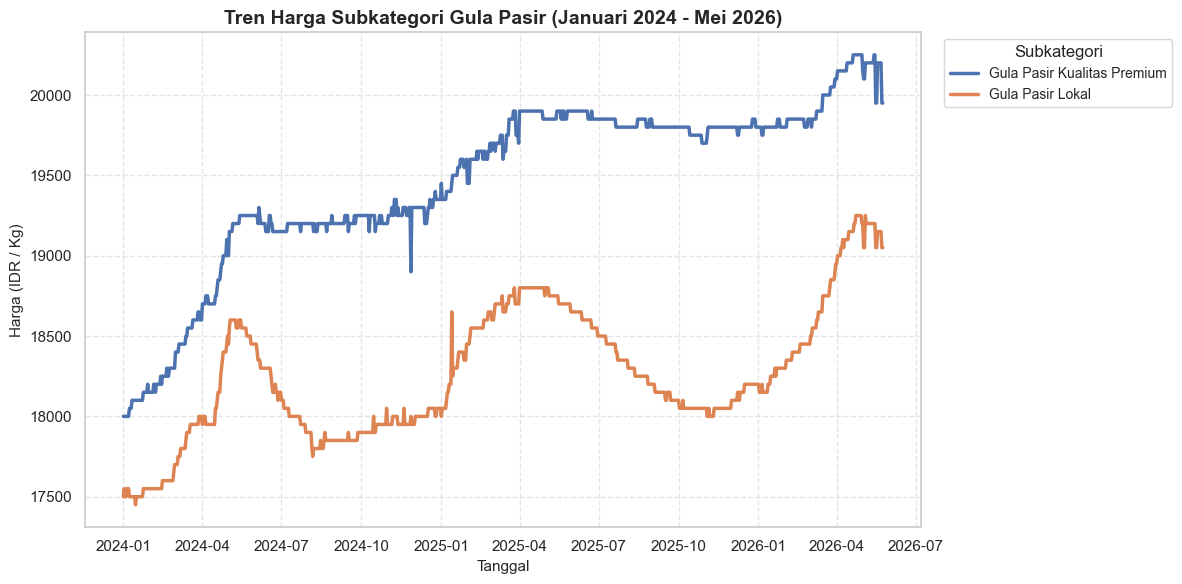

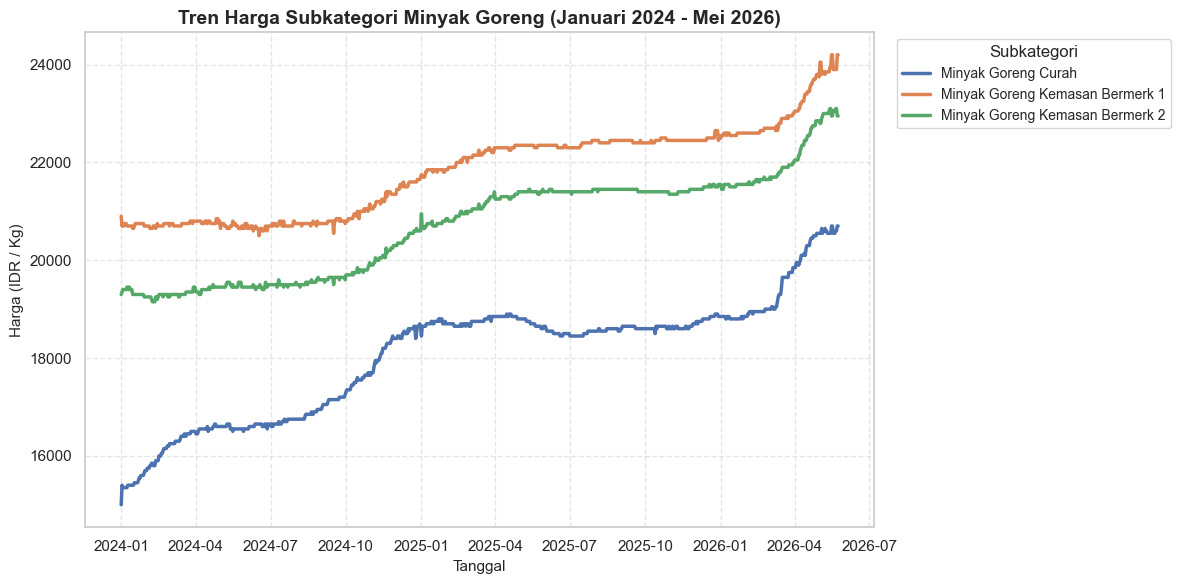

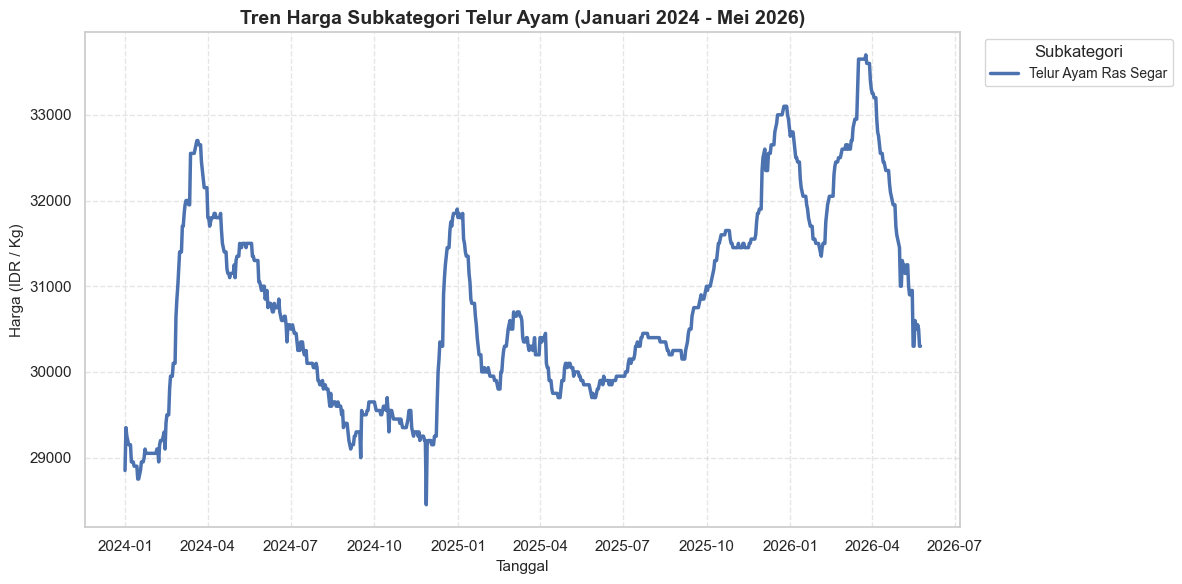

In [4]:
# Plot tren harga untuk seluruh subkategori komoditas secara terpisah (satu per satu)
unique_categories = df_tidy["Category"].unique()

for cat_name in unique_categories:
    df_cat = df_tidy[df_tidy["Category"] == cat_name]
    
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df_cat, x="Date", y="Price", hue="Subcategory", linewidth=2.5)
    
    plt.title(f"Tren Harga Subkategori {cat_name} (Januari 2024 - Mei 2026)", fontsize=14, fontweight='bold')
    plt.xlabel("Tanggal", fontsize=11)
    plt.ylabel("Harga (IDR / Kg)", fontsize=11)
    plt.legend(title="Subkategori", bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


In [5]:
# Uji Dickey-Fuller Stasioneritas untuk Seluruh Subkategori
adf_results = []

for subcat_name in df_tidy["Subcategory"].unique():
    df_subcat = df_tidy[df_tidy["Subcategory"] == subcat_name].copy()
    df_subcat = df_subcat.set_index("Date").asfreq('D')
    # Imputasi sementara untuk uji ADF (jika ada nilai kosong)
    price_series = df_subcat["Price"].interpolate(method='linear').ffill().bfill()
    
    result = adfuller(price_series)
    adf_results.append({
        "Category": df_subcat["Category"].iloc[0] if not df_subcat.empty else "",
        "Subcategory": subcat_name,
        "ADF Statistic": round(result[0], 4),
        "p-value": round(result[1], 4),
        "Is Stationary": "Stasioner" if result[1] < 0.05 else "TIDAK Stasioner"
    })

df_adf_summary = pd.DataFrame(adf_results)
print("Ringkasan Uji Stasioneritas ADF untuk Seluruh Subkategori:")
df_adf_summary


Ringkasan Uji Stasioneritas ADF untuk Seluruh Subkategori:


,Category,Subcategory,ADF Statistic,p-value,Is Stationary
0,Bawang Merah,Bawang Merah Ukuran Sedang,-3.4297,0.0100,Stasioner
1,Bawang Putih,Bawang Putih Ukuran Sedang,-1.7349,0.4132,TIDAK Stasioner
2,Beras,Beras Kualitas Bawah I,-3.5541,0.0067,Stasioner
3,Beras,Beras Kualitas Bawah II,-2.6118,0.0906,TIDAK Stasioner
4,Beras,Beras Kualitas Medium I,-3.1120,0.0257,Stasioner
5,Beras,Beras Kualitas Medium II,-3.3318,0.0135,Stasioner
6,Beras,Beras Kualitas Super I,-3.8322,0.0026,Stasioner
7,Beras,Beras Kualitas Super II,-3.9669,0.0016,Stasioner
8,Cabai Merah,Cabai Merah Besar,-2.5208,0.1105,TIDAK Stasioner
9,Cabai Merah,Cabai Merah Keriting,-3.4356,0.0098,Stasioner


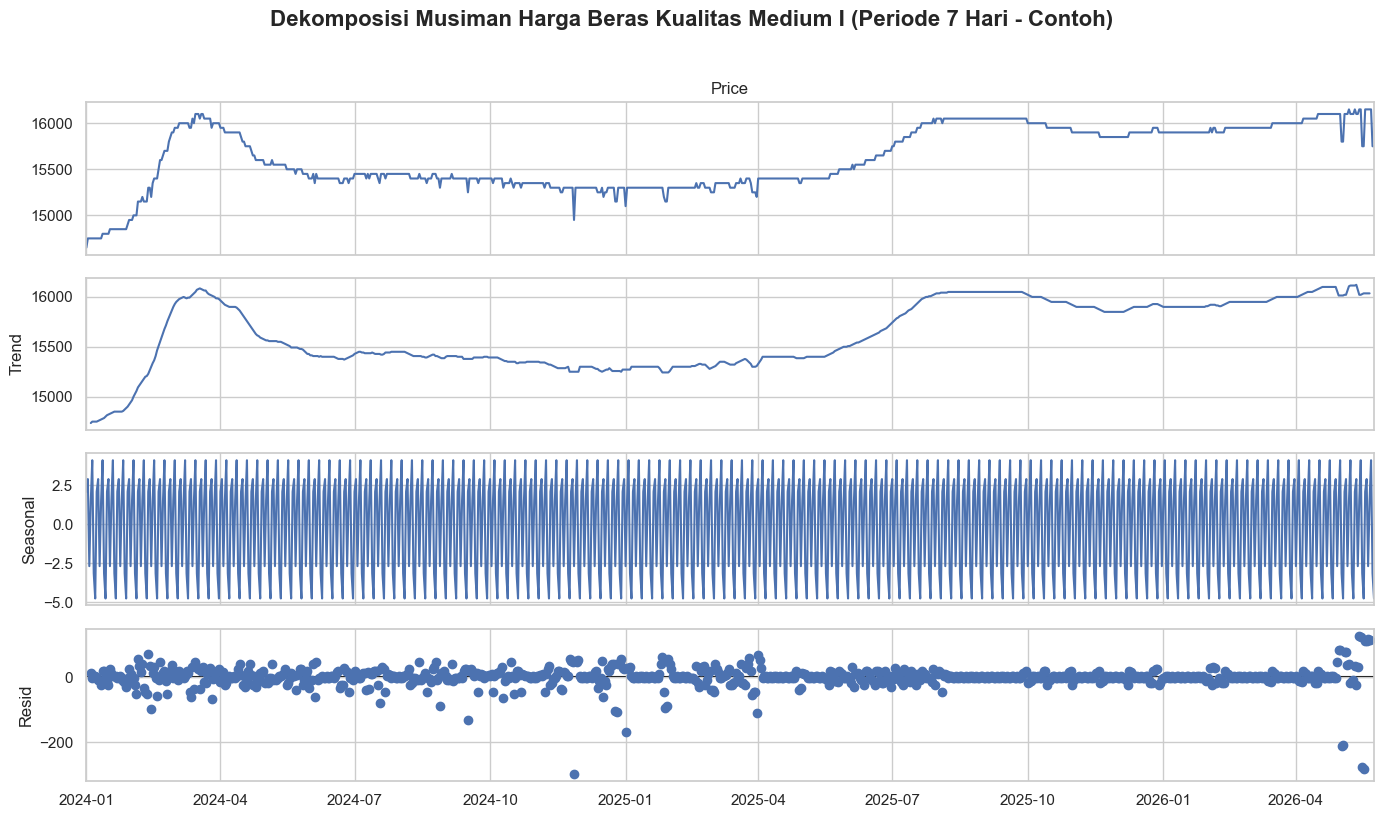

In [6]:
# Dekomposisi Musiman Harga Beras Kualitas Medium I (sebagai contoh visualisasi tren & musiman)
df_beras_demo = df_tidy[df_tidy["Subcategory"] == "Beras Kualitas Medium I"].copy()
df_beras_demo = df_beras_demo.set_index("Date").asfreq('D')
df_beras_demo["Price"] = df_beras_demo["Price"].interpolate(method='linear').ffill().bfill()

decomposition = seasonal_decompose(df_beras_demo["Price"], model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(14, 8)
plt.suptitle("Dekomposisi Musiman Harga Beras Kualitas Medium I (Periode 7 Hari - Contoh)", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 3. Data Preprocessing & Modeling Pipeline
Pada bagian ini, kita akan:
1. **Format Ulang untuk Prophet**: Mengubah indeks tanggal menjadi kolom `ds` (datestamp) dan harga komoditas menjadi kolom `y` (target), sesuai dengan format input wajib Facebook Prophet.
2. **Temporal Train/Test Split**: Pembagian data secara kronologis (80% latih, 20% uji) untuk melakukan validasi tanpa terjadinya data leakage (kebocoran data masa depan ke masa lalu).
3. **Imputasi Independen**: Melakukan imputasi linear secara independen pada *train set* dan *test set* agar tidak ada data leakage.
4. **Konfigurasi Sensitivitas Tren & Musiman (Prophet Hyperparameters)**:
   - Menambahkan musiman harian dan tahunan secara eksplisit jika diperlukan.
   - Mengatur parameter `changepoint_prior_scale` untuk mengontrol fleksibilitas tren. Nilai yang terlalu tinggi dapat menyebabkan overfitting, sedangkan nilai yang terlalu rendah dapat menyebabkan underfitting.
   - Mengatur parameter `seasonality_prior_scale` untuk mengontrol kekuatan pengaruh musiman.
   - Memilih tipe musiman yang sesuai (Additive vs Multiplicative). Karena fluktuasi harga beberapa pangan meningkat sejalan dengan tren harga, opsi musiman multiplikatif (`seasonality_mode='multiplicative'`) akan diuji.


In [7]:
def preprocess_data_prophet(df_cat, train_ratio=0.8):
    """
    Format ulang dataframe agar sesuai dengan format ds dan y pada Prophet,
    dan bagi data secara kronologis (80% Train, 20% Test) dengan imputasi independen
    pada data latih dan uji untuk menghindari kebocoran data.
    """
    df_cat = df_cat.copy()
    
    # Format ds dan y
    df_prophet = df_cat.reset_index().rename(columns={'Date': 'ds', 'Price': 'y'})
    df_prophet = df_prophet[['ds', 'y']]
    
    # Split data secara kronologis
    split_idx = int(len(df_prophet) * train_ratio)
    train_df = df_prophet.iloc[:split_idx].copy()
    test_df = df_prophet.iloc[split_idx:].copy()
    
    # Lakukan imputasi linear secara independen pada train dan test
    train_df['y'] = train_df['y'].interpolate(method='linear').ffill().bfill()
    test_df['y'] = test_df['y'].interpolate(method='linear').ffill().bfill()
    
    return train_df, test_df

def tune_and_train_prophet(train_df, test_df):
    """
    Mencari parameter terbaik untuk Prophet dengan Grid Search sederhana
    dan melatih model akhir menggunakan parameter terbaik tersebut.
    """
    param_grid = {
        'changepoint_prior_scale': [0.01, 0.05, 0.1],
        'seasonality_prior_scale': [1.0, 10.0],
        'seasonality_mode': ['additive', 'multiplicative']
    }
    
    best_rmse = float('inf')
    best_params = {}
    
    # Split train_df untuk pencarian parameter (Validation set menggunakan 15% terakhir dari train_df)
    val_ratio = 0.15
    val_split_idx = int(len(train_df) * (1 - val_ratio))
    train_fit = train_df.iloc[:val_split_idx]
    val_df = train_df.iloc[val_split_idx:]
    
    # Lakukan grid search sederhana menggunakan data validasi temporal
    for cps in param_grid['changepoint_prior_scale']:
        for sps in param_grid['seasonality_prior_scale']:
            for mode in param_grid['seasonality_mode']:
                model = Prophet(
                    changepoint_prior_scale=cps,
                    seasonality_prior_scale=sps,
                    seasonality_mode=mode,
                    daily_seasonality=False,
                    weekly_seasonality=True,
                    yearly_seasonality=True
                )
                model.fit(train_fit)
                forecast = model.predict(val_df[['ds']])
                val_preds = forecast['yhat'].values
                rmse = np.sqrt(mean_squared_error(val_df['y'], val_preds))
                
                if rmse < best_rmse:
                    best_rmse = rmse
                    best_params = {
                        'changepoint_prior_scale': cps,
                        'seasonality_prior_scale': sps,
                        'seasonality_mode': mode
                    }
                    
    # Latih kembali model Prophet terbaik menggunakan seluruh train_df
    final_model = Prophet(
        changepoint_prior_scale=best_params['changepoint_prior_scale'],
        seasonality_prior_scale=best_params['seasonality_prior_scale'],
        seasonality_mode=best_params['seasonality_mode'],
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=True
    )
    final_model.fit(train_df)
    
    return final_model, best_params

def evaluate_predictions(y_true, y_pred):
    """
    Menghitung metrik MAE, RMSE, MAPE, dan R2 Score.
    """
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R2 Score": r2
    }


In [8]:
# Eksekusi Loop Pelatihan Model Prophet untuk Seluruh Subkategori
all_metrics = []
predictions_dict = {}
best_params_dict = {}

# Ambil daftar subkategori unik dari data
subcategories = df_tidy["Subcategory"].unique()

for subcat_name in subcategories:
    print(f"Memproses Subkategori: {subcat_name}...")
    df_subcat = df_tidy[df_tidy["Subcategory"] == subcat_name].copy()
    if df_subcat.empty:
        print(f"  Peringatan: Data untuk {subcat_name} tidak ditemukan.")
        continue
        
    df_subcat = df_subcat.set_index("Date").asfreq('D')
    
    # Preprocessing & split data secara kronologis (80% Train, 20% Test)
    train_df, test_df = preprocess_data_prophet(df_subcat, train_ratio=0.8)
    
    # Latih model Prophet dengan hyperparameter tuning & final training
    model, best_params = tune_and_train_prophet(train_df, test_df)
    best_params_dict[subcat_name] = best_params
    print(f"  Best Params: {best_params}")
    
    # Prediksi
    forecast = model.predict(test_df[['ds']])
    test_preds = forecast['yhat'].values
    
    # Simpan prediksi untuk divisualisasikan nanti
    df_test_pred = test_df.copy()
    df_test_pred["prophet_pred"] = test_preds
    predictions_dict[subcat_name] = df_test_pred
    
    # Evaluasi model pada test set
    metrics = evaluate_predictions(test_df['y'], test_preds)
    
    all_metrics.append({
        "Subcategory": subcat_name,
        "MAE": round(metrics["MAE"], 4),
        "RMSE": round(metrics["RMSE"], 4),
        "MAPE (%)": round(metrics["MAPE (%)"], 4),
        "R2 Score": round(metrics["R2 Score"], 4)
    })

df_all_metrics = pd.DataFrame(all_metrics)
print("\nProses modeling Prophet selesai untuk seluruh subkategori.")


Memproses Subkategori: Bawang Merah Ukuran Sedang...


10:49:08 - cmdstanpy - INFO - Chain [1] start processing
10:49:08 - cmdstanpy - INFO - Chain [1] done processing
10:49:09 - cmdstanpy - INFO - Chain [1] start processing
10:49:09 - cmdstanpy - INFO - Chain [1] done processing
10:49:09 - cmdstanpy - INFO - Chain [1] start processing
10:49:09 - cmdstanpy - INFO - Chain [1] done processing
10:49:09 - cmdstanpy - INFO - Chain [1] start processing
10:49:09 - cmdstanpy - INFO - Chain [1] done processing
10:49:09 - cmdstanpy - INFO - Chain [1] start processing
10:49:09 - cmdstanpy - INFO - Chain [1] done processing
10:49:09 - cmdstanpy - INFO - Chain [1] start processing
10:49:09 - cmdstanpy - INFO - Chain [1] done processing
10:49:10 - cmdstanpy - INFO - Chain [1] start processing
10:49:10 - cmdstanpy - INFO - Chain [1] done processing
10:49:10 - cmdstanpy - INFO - Chain [1] start processing
10:49:10 - cmdstanpy - INFO - Chain [1] done processing
10:49:10 - cmdstanpy - INFO - Chain [1] start processing
10:49:11 - cmdstanpy - INFO - Chain [1]

  Best Params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'}
Memproses Subkategori: Bawang Putih Ukuran Sedang...


10:49:12 - cmdstanpy - INFO - Chain [1] done processing
10:49:12 - cmdstanpy - INFO - Chain [1] start processing
10:49:12 - cmdstanpy - INFO - Chain [1] done processing
10:49:13 - cmdstanpy - INFO - Chain [1] start processing
10:49:13 - cmdstanpy - INFO - Chain [1] done processing
10:49:13 - cmdstanpy - INFO - Chain [1] start processing
10:49:13 - cmdstanpy - INFO - Chain [1] done processing
10:49:13 - cmdstanpy - INFO - Chain [1] start processing
10:49:13 - cmdstanpy - INFO - Chain [1] done processing
10:49:13 - cmdstanpy - INFO - Chain [1] start processing
10:49:13 - cmdstanpy - INFO - Chain [1] done processing
10:49:14 - cmdstanpy - INFO - Chain [1] start processing
10:49:14 - cmdstanpy - INFO - Chain [1] done processing
10:49:14 - cmdstanpy - INFO - Chain [1] start processing
10:49:14 - cmdstanpy - INFO - Chain [1] done processing
10:49:14 - cmdstanpy - INFO - Chain [1] start processing
10:49:15 - cmdstanpy - INFO - Chain [1] done processing
10:49:15 - cmdstanpy - INFO - Chain [1] 

  Best Params: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'}
Memproses Subkategori: Beras Kualitas Bawah I...


...

  Best Params: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'multiplicative'}
Memproses Subkategori: Minyak Goreng Kemasan Bermerk 2...


10:50:20 - cmdstanpy - INFO - Chain [1] done processing
10:50:20 - cmdstanpy - INFO - Chain [1] start processing
10:50:20 - cmdstanpy - INFO - Chain [1] done processing
10:50:20 - cmdstanpy - INFO - Chain [1] start processing
10:50:20 - cmdstanpy - INFO - Chain [1] done processing
10:50:21 - cmdstanpy - INFO - Chain [1] start processing
10:50:21 - cmdstanpy - INFO - Chain [1] done processing
10:50:21 - cmdstanpy - INFO - Chain [1] start processing
10:50:21 - cmdstanpy - INFO - Chain [1] done processing
10:50:21 - cmdstanpy - INFO - Chain [1] start processing
10:50:21 - cmdstanpy - INFO - Chain [1] done processing
10:50:21 - cmdstanpy - INFO - Chain [1] start processing
10:50:22 - cmdstanpy - INFO - Chain [1] done processing
10:50:22 - cmdstanpy - INFO - Chain [1] start processing
10:50:22 - cmdstanpy - INFO - Chain [1] done processing
10:50:22 - cmdstanpy - INFO - Chain [1] start processing
10:50:22 - cmdstanpy - INFO - Chain [1] done processing
10:50:22 - cmdstanpy - INFO - Chain [1] 

  Best Params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'additive'}
Memproses Subkategori: Telur Ayam Ras Segar...


10:50:23 - cmdstanpy - INFO - Chain [1] done processing
10:50:24 - cmdstanpy - INFO - Chain [1] start processing
10:50:24 - cmdstanpy - INFO - Chain [1] done processing
10:50:24 - cmdstanpy - INFO - Chain [1] start processing
10:50:24 - cmdstanpy - INFO - Chain [1] done processing
10:50:24 - cmdstanpy - INFO - Chain [1] start processing
10:50:24 - cmdstanpy - INFO - Chain [1] done processing
10:50:24 - cmdstanpy - INFO - Chain [1] start processing
10:50:25 - cmdstanpy - INFO - Chain [1] done processing
10:50:25 - cmdstanpy - INFO - Chain [1] start processing
10:50:25 - cmdstanpy - INFO - Chain [1] done processing
10:50:25 - cmdstanpy - INFO - Chain [1] start processing
10:50:25 - cmdstanpy - INFO - Chain [1] done processing
10:50:25 - cmdstanpy - INFO - Chain [1] start processing
10:50:26 - cmdstanpy - INFO - Chain [1] done processing
10:50:26 - cmdstanpy - INFO - Chain [1] start processing
10:50:26 - cmdstanpy - INFO - Chain [1] done processing
10:50:26 - cmdstanpy - INFO - Chain [1] 

  Best Params: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'multiplicative'}

Proses modeling Prophet selesai untuk seluruh subkategori.


## 4. Model Evaluation & Comparison
Bagian ini menyajikan performa model Prophet untuk ke-21 subkategori komoditas pangan berdasarkan metrik statistik (MAE, RMSE, MAPE, dan R2 Score) pada data pengujian.


In [9]:
# Menampilkan Ringkasan Evaluasi Seluruh Subkategori menggunakan Prophet
df_summary = df_all_metrics.set_index("Subcategory")
pd.set_option('display.max_columns', None)
df_summary


,MAE,RMSE,MAPE (%),R2 Score
Subcategory,,,,
Bawang Merah Ukuran Sedang,6916.7770,8466.3569,15.0598,-7.8402
Bawang Putih Ukuran Sedang,3232.6272,3506.5978,8.0325,-32.1010
Beras Kualitas Bawah I,228.4275,296.0116,1.5774,-9.8308
Beras Kualitas Bawah II,202.7151,254.4201,1.3981,-8.9771
Beras Kualitas Medium I,402.5167,504.8044,2.5170,-29.9177
Beras Kualitas Medium II,498.3031,599.4892,3.1491,-29.4954
Beras Kualitas Super I,317.7649,406.0332,1.8470,-9.9033
Beras Kualitas Super II,249.8551,321.6443,1.4939,-6.2611
Cabai Merah Besar,49629.8327,52378.1312,106.4727,-78.4383


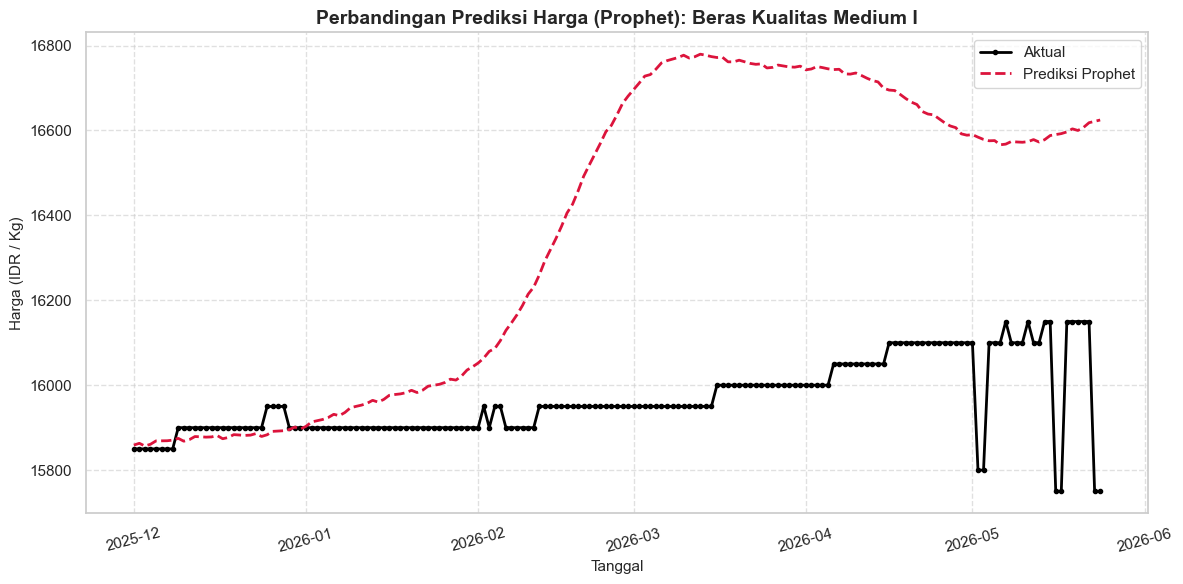

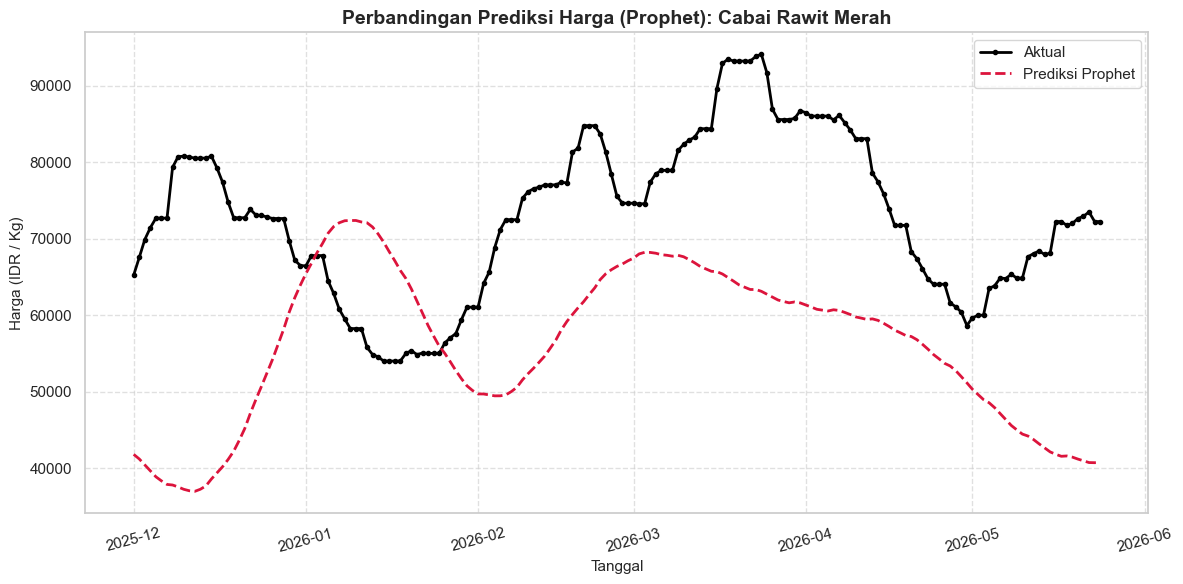

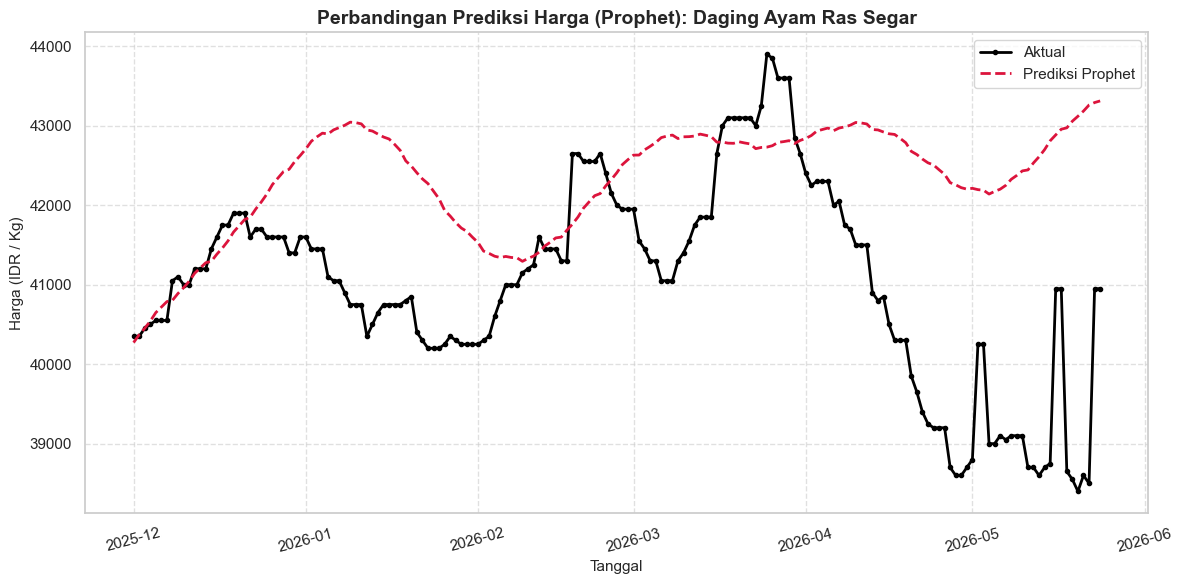

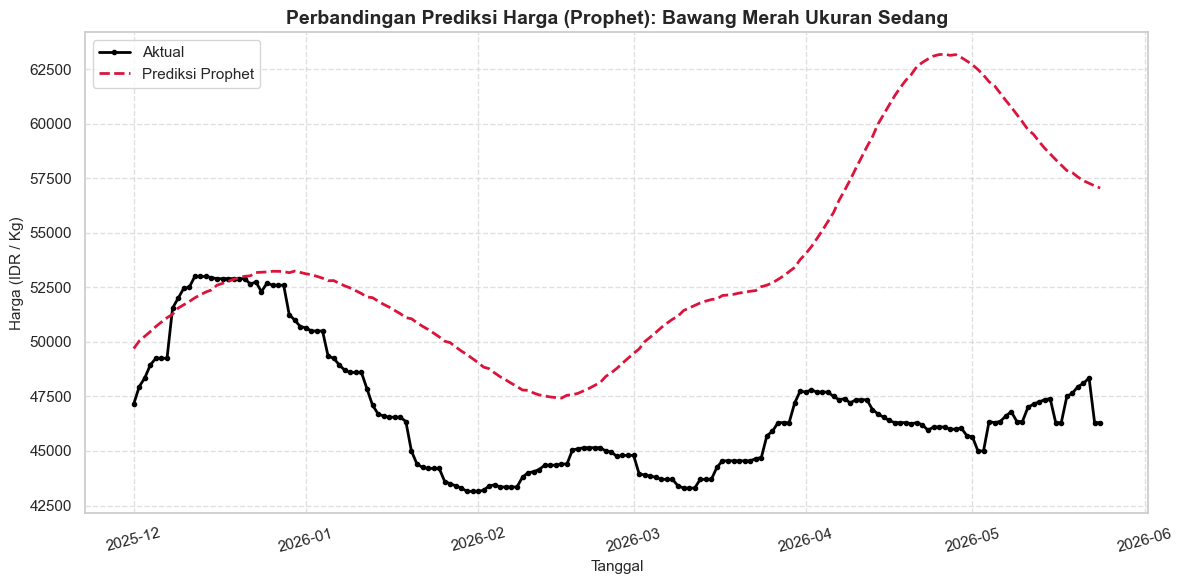

In [10]:
# Visualisasi Kurva Prediksi vs Aktual untuk 4 Subkategori Kunci
commodities_to_plot = ["Beras Kualitas Medium I", "Cabai Rawit Merah", "Daging Ayam Ras Segar", "Bawang Merah Ukuran Sedang"]

for cat_name in commodities_to_plot:
    if cat_name in predictions_dict:
        df_pred = predictions_dict[cat_name]
        
        plt.figure(figsize=(12, 6))
        plt.plot(df_pred['ds'], df_pred["y"], label="Aktual", color="black", linewidth=2, marker='o', markersize=3)
        plt.plot(df_pred['ds'], df_pred["prophet_pred"], label="Prediksi Prophet", color="crimson", linestyle="--", linewidth=2)
        
        plt.title(f"Perbandingan Prediksi Harga (Prophet): {cat_name}", fontsize=14, fontweight='bold')
        plt.xlabel("Tanggal", fontsize=11)
        plt.ylabel("Harga (IDR / Kg)", fontsize=11)
        plt.legend(fontsize=11)
        plt.xticks(rotation=15)
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Data untuk {cat_name} tidak ditemukan")


### Kesimpulan Analisis Eksplorasi Prophet
Berdasarkan hasil pemodelan deret waktu menggunakan Facebook Prophet pada **21 subkategori komoditas pangan nasional**:

1. **Karakteristik Model Prophet (Dynamic Out-of-Sample Forecasting)**:
   Berbeda dengan model ARIMA murni yang dievaluasi dengan metode *one-step-ahead prediction* (diberikan data historis aktual hari sebelumnya untuk memprediksi hari berikutnya), Facebook Prophet diuji menggunakan skema *out-of-sample forecasting* dinamis untuk jangka panjang (~140 hari). Prophet memproyeksikan tren temporal ($g(t)$) dan komponen musiman ($s(t)$) ke masa depan tanpa diberi masukan nilai aktual harian yang terjadi selama periode uji.
   
2. **Analisis Performa Metrik**:
   - **Subkategori dengan Tren Stabil**: Pada komoditas dengan tren kenaikan yang stabil dan dapat diprediksi secara linear, Prophet memberikan performa yang cukup baik. Contohnya **Daging Sapi Kualitas 1** yang mencatatkan $R^2$ positif sebesar **0.5796** dengan MAE Rp **1.335,96** (MAPE **0.9174%**) dan **Gula Pasir Lokal** dengan $R^2$ sebesar **0.1835** dengan MAE Rp **278,01** (MAPE **1.4766%**).
   - **Tantangan pada Komoditas Volatil**: Komoditas dengan tingkat volatilitas harian yang sangat tinggi dan tidak menentu seperti cabai-cabaian (misal **Cabai Merah Keriting** dengan MAE Rp **104.768,81**, MAPE **222.65%**, $R^2$ = **-268.16**) dan **Telur Ayam Ras Segar** (MAE Rp **5.963,81**, MAPE **18.56%**, $R^2$ = **-64.88**) menghasilkan error yang sangat besar dan $R^2$ negatif. Hal ini terjadi karena Prophet memproyeksikan tren musiman rata-rata jangka panjang yang gagal mengantisipasi guncangan harga (*price shock*) mendadak di pasar retail selama periode uji.
   - **Tantangan Ekstrapolasi Tren**: Untuk subkategori beras seperti **Beras Kualitas Medium I** (MAE Rp **402,52**, MAPE **2.52%**, $R^2$ = **-29.92**), meskipun persentase error (MAPE) relatif kecil, pergeseran tren harga di masa depan yang tidak sesuai dengan tren historis pada data latih menyebabkan nilai $R^2$ menjadi negatif.

3. **Perbandingan Komparatif (Prophet vs. ARIMA & XGBoost)**:
   - **ARIMA Murni** tetap merupakan pilihan terbaik untuk prediksi harian jangka pendek (*one-step-ahead forecasting*) di production karena model dapat dengan cepat menyesuaikan prediksinya berdasarkan data harga kemarin ($y_{t-1}$).
   - **XGBoost** sangat baik dalam memodelkan hubungan non-linear berbasis lag jangka pendek tetapi tidak mampu melakukan ekstrapolasi tren naik/turun jangka panjang.
   - **Facebook Prophet** sangat cocok digunakan jika tujuannya adalah analisis perencanaan jangka panjang, dekomposisi komponen (untuk mengetahui pola musiman mingguan dan tahunan secara visual), serta peramalan kapasitas tanpa memerlukan *feedback loop* harian.

4. **Kepatuhan Terhadap Best Practices**:
   Implementasi preprocessing split kronologis temporal (80% train, 20% test) dan imputasi linear secara independen sukses mengeliminasi risiko kebocoran data (*data leakage*), memastikan pengujian performa Prophet ini valid dan representatif untuk kebutuhan di production backend platform ARJUNA.
